In [ ]:
import colorsys
import pathlib
import tempfile
import urllib.request

In [ ]:
import marimo as mo
from matplotlib.colors import SymLogNorm
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, ScalarFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-07-28T14:19:54.542990+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1062-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

marimo    : 0.23.2
pandas    : 2.2.3
teeplot   : 1.4.2
numpy     : 2.1.2
seaborn   : 0.13.2
matplotlib: 3.9.2

```

# Exploratory sweep (2026-07-27): double-descent analysis

Downloads the collated timeseries parquet file for the
`2026-07-27-exploratory-sweep` SLURM batch job (see
`slurm/2026-07-27/`) from OSF, then -- for each swept condition (blip
frequency, L1/L2 regularization mix, zero-init, and environment
schedule mode) -- renders a compound plot summarizing training/testing
dynamics, phenotype composition, and double descent across model size
`v` and training time.

Unlike the `2026-07-23-exploratory-sweep`/`-noblip` pair, this sweep
folds the no-blip control into the same job as `blip_freq=0` (one of
its 5 swept blip frequencies) rather than a separate job/dataset, and
narrows `v` to `{0, 4, 8, 12, 16, 20}` and `schedule_mode` to
`{none, local}`.

## Fetch data

In [ ]:
# https://osf.io/36qrb -- 2026-07-27-exploratory-sweep collated timeseries
#   (blip_freq swept across {0, 0.1, 0.2, 0.33, 0.5})
OSF_SLUGS = {
    "exploratory-sweep": "36qrb",
}

In [ ]:
def fetch_osf(slug: str) -> "pathlib.Path":
    """Download a file from OSF by its slug, caching it under the system
    temp directory, and return the path to the cached file.

    Tries a plain stdlib download first; if that fails for any reason
    (auth wall, transient network error, redirect handling, ...) falls
    back to the `osf_fetch` utility from this project's `pylib` (ported
    from the same-named utility added to
    github.com/mmore500/paperproject.git), which is more robust
    (session handling via `requests`, on-disk caching)."""
    cache_path = pathlib.Path(tempfile.gettempdir()) / slug
    url = f"https://osf.io/{slug}/download"
    try:
        if not cache_path.exists():
            print(f"downloading {url} -> {cache_path}")
            request = urllib.request.Request(
                url, headers={"User-Agent": "evodd-bindle/1.0"}
            )
            with urllib.request.urlopen(request, timeout=180) as resp:
                cache_path.write_bytes(resp.read())
        else:
            print(f"reusing cached {cache_path}")
    except Exception as e:
        print(
            f"direct download of {url} failed ({e!r}), falling back to pylib.osf_fetch"
        )
        from pylib import osf_fetch

        cache_path = osf_fetch(slug)
    print(f"size: {cache_path.stat().st_size} bytes")
    return cache_path

In [ ]:
osf_paths = {name: fetch_osf(slug) for name, slug in OSF_SLUGS.items()}

downloading https://osf.io/36qrb/download -> /tmp/36qrb
direct download of https://osf.io/36qrb/download failed (<HTTPError 308: 'Permanent Redirect'>), falling back to pylib.osf_fetch
downloading https://osf.io/36qrb/download -> /tmp/36qrb
size: 278412527 bytes
size: 278412527 bytes


## Load data

In [ ]:
df = pd.concat(
    [
        pd.read_parquet(path).assign(dataset=name)
        for name, path in osf_paths.items()
    ],
    ignore_index=True,
)
df["dataset"] = pd.Categorical(df["dataset"])

In [ ]:
pd.concat([df.head(), df.tail()])

,epoch,generation,walltime_sec,pure_train_chi2,test_chi2,blip_train_chi2,test1_frac,test2_frac,test3_frac,test4_frac,...,v,seed,zero_init,l1_scale,l2_scale,blip_freq,num_epoch,schedule_mode,replicate_uid,dataset
0,0,0,61.172480,1.000000,1.000000,1.0,0.0,0.0,0.0,0.0,...,0,1,True,1.0,0.0,0.0,138889,none,36ddcb83-2c3a-4f05-9d2e-4aa07d044c51,exploratory-sweep
1,1,138889,61.227315,1.000000,1.000000,1.0,0.0,0.0,0.0,0.0,...,0,1,True,1.0,0.0,0.0,138889,none,36ddcb83-2c3a-4f05-9d2e-4aa07d044c51,exploratory-sweep
2,2,277778,61.245078,1.000000,1.000000,1.0,0.0,0.0,0.0,0.0,...,0,1,True,1.0,0.0,0.0,138889,none,36ddcb83-2c3a-4f05-9d2e-4aa07d044c51,exploratory-sweep
3,3,416667,61.274753,1.000000,1.000000,1.0,0.0,0.0,0.0,0.0,...,0,1,True,1.0,0.0,0.0,138889,none,36ddcb83-2c3a-4f05-9d2e-4aa07d044c51,exploratory-sweep
4,4,555556,61.303353,1.000000,1.000000,1.0,0.0,0.0,0.0,0.0,...,0,1,True,1.0,0.0,0.0,138889,none,36ddcb83-2c3a-4f05-9d2e-4aa07d044c51,exploratory-sweep
4026955,2392,499028177,4273.523533,0.998003,0.998008,1.0,0.0,0.0,0.0,0.0,...,0,1,False,1.0,0.0,0.1,138889,local,4ad6f21f-f818-417f-96c9-20cbc8585421,exploratory-sweep
4026956,2393,499167066,4273.537602,0.998003,0.998008,1.0,0.0,0.0,0.0,0.0,...,0,1,False,1.0,0.0,0.1,138889,local,4ad6f21f-f818-417f-96c9-20cbc8585421,exploratory-sweep
4026957,2394,499444844,4273.551663,0.998003,0.998008,1.0,0.0,0.0,0.0,0.0,...,0,1,False,1.0,0.0,0.1,138889,local,4ad6f21f-f818-417f-96c9-20cbc8585421,exploratory-sweep
4026958,2395,499583733,4273.565878,0.998003,0.998008,1.0,0.0,0.0,0.0,0.0,...,0,1,False,1.0,0.0,0.1,138889,local,4ad6f21f-f818-417f-96c9-20cbc8585421,exploratory-sweep
4026959,2396,500000400,4273.579903,0.998003,0.998008,1.0,0.0,0.0,0.0,0.0,...,0,1,False,1.0,0.0,0.1,138889,local,4ad6f21f-f818-417f-96c9-20cbc8585421,exploratory-sweep


In [ ]:
df.describe()

,epoch,generation,walltime_sec,pure_train_chi2,test_chi2,blip_train_chi2,test1_frac,test2_frac,test3_frac,test4_frac,...,other_n_classes,l1_loss,l2_loss,regularization_loss,v,seed,l1_scale,l2_scale,blip_freq,num_epoch
count,4.026960e+06,4.026960e+06,4.026960e+06,4.026960e+06,4.026960e+06,4.026960e+06,4.026960e+06,4.026960e+06,4.026960e+06,4.026960e+06,...,4.026960e+06,4.026960e+06,4.026960e+06,4.026960e+06,4.026960e+06,4.026960e+06,4.026960e+06,4.026960e+06,4.026960e+06,4026960.0
mean,1.198000e+03,2.298660e+08,3.153553e+03,3.754925e-01,2.165334e-01,9.782078e-01,1.381443e-01,1.004484e-01,9.083435e-02,1.393516e-01,...,9.699073e+01,6.969660e-02,4.961107e-02,1.792396e-02,1.142857e+01,2.428571e+00,9.984000e-01,1.500000e-03,2.260000e-01,138889.0
std,6.919543e+02,1.484460e+08,2.202305e+03,2.128357e-01,3.238987e-01,5.083671e-02,6.281917e-02,4.035628e-02,4.339924e-02,6.086632e-02,...,3.552522e+02,2.126441e-02,3.281691e-02,5.755835e-03,6.083322e+00,1.136889e+00,1.256981e-03,1.118034e-03,1.752256e-01,0.0
min,0.000000e+00,0.000000e+00,6.106081e+01,2.419075e-02,0.000000e+00,4.199120e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,9.966000e-01,0.000000e+00,0.000000e+00,138889.0
25%,5.990000e+02,9.513896e+07,1.243310e+03,3.078057e-01,1.708000e-03,9.880375e-01,1.180000e-01,7.200000e-02,5.400000e-02,1.205000e-01,...,4.000000e+00,7.131332e-02,3.391645e-02,1.767415e-02,8.000000e+00,1.000000e+00,9.976500e-01,7.500000e-04,1.000000e-01,138889.0
50%,1.198000e+03,2.216668e+08,2.910281e+03,3.906310e-01,5.998000e-03,1.000000e+00,1.255000e-01,1.220000e-01,1.140000e-01,1.280000e-01,...,1.000000e+01,7.558662e-02,4.180429e-02,1.933435e-02,1.200000e+01,2.000000e+00,9.985000e-01,1.500000e-03,2.000000e-01,138889.0
75%,1.797000e+03,3.584725e+08,4.703491e+03,4.022815e-01,4.111705e-01,1.000000e+00,1.475000e-01,1.280000e-01,1.250000e-01,1.480000e-01,...,2.400000e+01,7.963302e-02,6.426336e-02,2.061338e-02,1.600000e+01,3.000000e+00,9.992500e-01,2.250000e-03,3.300000e-01,138889.0
max,2.396000e+03,5.000004e+08,1.228888e+04,1.000000e+00,1.152060e+00,1.000000e+00,4.145000e-01,2.810000e-01,2.355000e-01,4.065000e-01,...,2.000000e+03,1.115090e-01,1.649950e-01,2.879497e-02,2.000000e+01,4.000000e+00,1.000000e+00,3.000000e-03,5.000000e-01,138889.0


## Prepare conditions

A "condition" is one unique combination of the swept, non-model-size
knobs (`blip_freq`, `l1_scale`, `l2_scale`, `zero_init`,
`schedule_mode`) within a dataset -- everything except model size `v`
(the double-descent x-axis) and `seed` (the replicate axis).

In [ ]:
CONDITION_COLS = [
    "dataset",
    "blip_freq",
    "l1_scale",
    "l2_scale",
    "zero_init",
    "schedule_mode",
]

conditions = (
    df[CONDITION_COLS].drop_duplicates().sort_values(CONDITION_COLS)
)

# categorical (qualitative) color map for v, shared across every plot
# below that encodes v via color.
v_values_all = sorted(df["v"].unique())
v_palette = dict(
    zip(
        v_values_all,
        sns.color_palette("tab20", n_colors=len(v_values_all)),
    )
)

In [ ]:
pd.concat([conditions.head(), conditions.tail()])

,dataset,blip_freq,l1_scale,l2_scale,zero_init,schedule_mode
11985,exploratory-sweep,0.0,0.9966,0.003,False,local
9588,exploratory-sweep,0.0,0.9966,0.003,False,none
7191,exploratory-sweep,0.0,0.9966,0.003,True,local
4794,exploratory-sweep,0.0,0.9966,0.003,True,none
64719,exploratory-sweep,0.0,0.9980,0.002,False,local
1327938,exploratory-sweep,0.5,0.9990,0.001,True,none
1277601,exploratory-sweep,0.5,1.0000,0.000,False,local
1275204,exploratory-sweep,0.5,1.0000,0.000,False,none
1224867,exploratory-sweep,0.5,1.0000,0.000,True,local
1222470,exploratory-sweep,0.5,1.0000,0.000,True,none


## Plotting helpers

Phenotype classes `test1_frac`..`test8_frac` are the 8 canonical
`CLASS_8` phenotypes; `train1_frac`..`train3_frac` duplicate
`test1_frac`/`test4_frac`/`test7_frac` by construction (see
`bindle/2026-07-23-exploratory.py`'s `_trace_row`), so the phenotype
stackplot below stacks `test1_frac`..`test8_frac` (not the `train*`
columns, which would double-count) and simply recolors the 3
training-overlap slices distinctly from the other 5 test-only slices.
Blip-pattern matches (`s1_blip_match_frac`..`s3_blip_match_frac`) are a
subset of `other_frac`, so they're broken out of it rather than stacked
on top.

In [ ]:
# CLASS_8 indices 0,3,6 (1-indexed: test1,test4,test7) are the pure
# training patterns S1,S2,S3.
TRAIN_OVERLAP_TEST_IDX = [1, 4, 7]
TEST_ONLY_IDX = [2, 3, 5, 6, 8]

def dull(hex_color, sat_scale=0.35, light_boost=0.25):
    """Desaturate + lighten a bright hex color for the "testing" (as
    opposed to bright "training") stackplot palette."""
    r, g, b = (int(hex_color[i : i + 2], 16) / 255 for i in (1, 3, 5))
    hue, lightness, sat = colorsys.rgb_to_hls(r, g, b)
    lightness = min(1.0, lightness + light_boost)
    sat = sat * sat_scale
    return colorsys.hls_to_rgb(hue, lightness, sat)

BRIGHT_TRAIN_COLORS = ["#e6194B", "#3cb44b", "#4363d8"]
DULL_TEST_COLORS = [dull(c) for c in BRIGHT_TRAIN_COLORS] + [
    dull("#f58231"),
    dull("#911eb4"),
]
GRAY_BLIP_COLORS = ["#404040", "#808080", "#bfbfbf"]
OTHER_COLOR = "#ffffff"

In [ ]:
def _use_readable_symlog_ticks(axis):
    # matplotlib's default symlog locator/formatter collapses to a
    # single offset-notation label (instead of normal tick labels)
    # whenever the visible range never actually crosses linthresh
    # -- MaxNLocator + ScalarFormatter reads fine in that case *and*
    # when the range does cross into the log region.
    axis.set_major_locator(MaxNLocator(nbins=6))
    axis.set_major_formatter(ScalarFormatter())

def make_compound_plot(df_cond, v_palette):
    # every generation-axis (log-scaled) plot below starts at 10^6,
    # not 1 -- drop earlier rows up front so they don't skew
    # autoscaled y-limits or inflate rendered path complexity for
    # data that's off the visible window anyway.
    GEN_LOG_FLOOR = 1e6
    df_cond = df_cond[df_cond["generation"] >= GEN_LOG_FLOOR]

    # chi^2 loss/error axes (and the heatmap's color axis) use
    # symlog -- linear below this threshold, log above -- since
    # chi2 values cluster near 0 as v/generation improve but can
    # spike much higher (up to ~k-1 for k classes) early on.
    CHI2_LINTHRESH = 1.0

    v_values = sorted(df_cond["v"].unique())
    n_v = len(v_values)

    # dpi is deliberately low -- this controls only the resolution
    # of the preview marimo embeds in the notebook cell output
    # (which needs to stay within output_max_bytes across every
    # condition's plot in the loop below); the teeplot-saved
    # PDF/PNG files keep their own full-resolution dpi regardless,
    # since teeplot_dpi isn't tied to this figure's dpi.
    fig = plt.figure(figsize=(max(10, 2.0 * n_v), 24), dpi=32)
    gs = GridSpec(
        5,
        1,
        figure=fig,
        height_ratios=[3, 2.4, 2.6, 2.4, 3.2],
        hspace=0.55,
    )

    # --- row 1: testing (solid) / ACTUAL training (dashed) loss over
    # generations, faceted by v, one line per replicate.
    row1_gs = GridSpecFromSubplotSpec(
        1, n_v, subplot_spec=gs[0], wspace=0.08
    )
    axes1 = [fig.add_subplot(row1_gs[0, 0])]
    for i in range(1, n_v):
        axes1.append(fig.add_subplot(row1_gs[0, i], sharey=axes1[0]))
    seed_values = sorted(df_cond["seed"].unique())
    seed_palette = dict(
        zip(
            seed_values,
            sns.color_palette("tab10", n_colors=len(seed_values)),
        )
    )
    for ax, v in zip(axes1, v_values):
        sub = df_cond[df_cond["v"] == v]
        for seed, g in sub.groupby("seed", observed=True):
            g = g.sort_values("generation")
            color = seed_palette[seed]
            ax.plot(
                g["generation"],
                g["test_chi2"],
                color=color,
                ls="-",
                lw=1.2,
            )
            ax.plot(
                g["generation"],
                g["pure_train_chi2"],
                color=color,
                ls="--",
                lw=1.2,
            )
        ax.set_xscale("log")
        ax.set_xlim(left=GEN_LOG_FLOOR)
        ax.set_yscale("symlog", linthresh=CHI2_LINTHRESH)
        ax.set_ylim(bottom=0)
        _use_readable_symlog_ticks(ax.yaxis)
        ax.set_title(f"v={v}", fontsize=9, color=v_palette[v])
        ax.set_xlabel("generation", fontsize=7)
        ax.tick_params(labelsize=7)
        if ax is not axes1[0]:
            plt.setp(ax.get_yticklabels(), visible=False)
    axes1[0].set_ylabel("chi$^2$ error")
    legend_handles = [
        plt.Line2D([], [], color="black", ls="-", label="testing"),
        plt.Line2D(
            [], [], color="black", ls="--", label="training (actual)"
        ),
    ] + [
        plt.Line2D(
            [], [], color=seed_palette[s], label=f"replicate seed={s}"
        )
        for s in seed_values
    ]
    axes1[-1].legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        fontsize=7,
        frameon=False,
    )

    # --- row 2: median +/- [0th, 100th] percentile band across
    # replicates, training error | testing error, hue=v.
    row2_gs = GridSpecFromSubplotSpec(
        1, 2, subplot_spec=gs[1], wspace=0.15
    )
    ax_train = fig.add_subplot(row2_gs[0, 0])
    ax_test = fig.add_subplot(row2_gs[0, 1])
    for metric_col, ax, label in (
        ("pure_train_chi2", ax_train, "training error (actual)"),
        ("test_chi2", ax_test, "testing error"),
    ):
        agg = (
            df_cond.groupby(["v", "generation"], observed=True)[metric_col]
            .agg(median="median", lo="min", hi="max")
            .reset_index()
        )
        for v, g in agg.groupby("v", observed=True):
            g = g.sort_values("generation")
            color = v_palette[v]
            ax.plot(
                g["generation"],
                g["median"],
                color=color,
                lw=1.5,
                label=f"v={v}",
            )
            ax.fill_between(
                g["generation"],
                g["lo"],
                g["hi"],
                color=color,
                alpha=0.2,
                lw=0,
            )
        ax.set_xscale("log")
        ax.set_xlim(left=GEN_LOG_FLOOR)
        ax.set_yscale("symlog", linthresh=CHI2_LINTHRESH)
        ax.set_ylim(bottom=0)
        _use_readable_symlog_ticks(ax.yaxis)
        ax.set_xlabel("generation")
        ax.set_title(label, fontsize=10)
    ax_train.set_ylabel("chi$^2$ error")
    ax_test.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        fontsize=7,
        frameon=False,
        title="v",
    )

    # --- row 3: stackplot of testing phenotype distributions across v,
    # at each replicate's own final recorded generation. Bright =
    # training classes (overlap with test1/test4/test7), dull =
    # test-only classes, grayscale = blip matches, white = remaining
    # "other". Per-(v, seed) last-row (rather than a single shared max
    # generation across the whole condition) since replicates can be
    # truncated at different generations by a SLURM timeout (see
    # bindle/2026-07-23-exploratory.py's progressive save-out).
    ax3 = fig.add_subplot(gs[2])
    final = (
        df_cond.sort_values("generation")
        .groupby(["v", "seed"], observed=True)
        .tail(1)
    )
    frac_cols = [f"test{i}_frac" for i in range(1, 9)]
    blip_cols = [f"s{i}_blip_match_frac" for i in range(1, 4)]
    med = (
        final.groupby("v", observed=True)[
            frac_cols + blip_cols + ["other_frac"]
        ]
        .median()
        .reindex(v_values)
    )
    blip_sum = med[blip_cols].sum(axis=1)
    # blip matches are a subset of "other" (they don't coincide with
    # any of the 8 canonical CLASS_8 phenotypes) -- subtract them back
    # out so the stack doesn't double-count; clip guards against
    # floating-point/rare-coincidence edge cases.
    other_only = (med["other_frac"] - blip_sum).clip(lower=0)

    train_layers = [med[f"test{i}_frac"] for i in TRAIN_OVERLAP_TEST_IDX]
    test_only_layers = [med[f"test{i}_frac"] for i in TEST_ONLY_IDX]
    blip_layers = [med[c] for c in blip_cols]

    stack = train_layers + test_only_layers + blip_layers + [other_only]
    colors = (
        BRIGHT_TRAIN_COLORS
        + DULL_TEST_COLORS
        + GRAY_BLIP_COLORS
        + [OTHER_COLOR]
    )
    labels = (
        [f"train (test{i})" for i in TRAIN_OVERLAP_TEST_IDX]
        + [f"test-only (test{i})" for i in TEST_ONLY_IDX]
        + [f"blip s{i}" for i in range(1, 4)]
        + ["other"]
    )
    polys = ax3.stackplot(v_values, *stack, colors=colors, labels=labels)
    # "other" is white -- outline it so it's visible against the
    # figure background.
    polys[-1].set_edgecolor("black")
    polys[-1].set_linewidth(0.6)
    ax3.set_xlim(min(v_values), max(v_values))
    ax3.set_ylim(0, 1)
    ax3.set_xlabel("v (visible genes)")
    ax3.set_ylabel("phenotype fraction")
    ax3.set_title(
        "final-generation testing phenotype distribution across v",
        fontsize=10,
    )
    ax3.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        fontsize=7,
        frameon=False,
        ncol=1,
    )

    # --- row 4: final training (actual) / testing loss vs model size
    # v -- reuses `final` (each replicate's own last recorded row,
    # computed above for row 3) so truncated replicates are handled
    # the same way here; median with a shaded [0th, 100th] percentile
    # band across replicates per v, testing solid / training (actual)
    # dashed to match row 1's convention.
    ax_final = fig.add_subplot(gs[3])
    final_loss = (
        final.groupby("v", observed=True)[["pure_train_chi2", "test_chi2"]]
        .agg(["median", "min", "max"])
        .reindex(v_values)
    )
    for metric_col, color, ls, label in (
        ("test_chi2", "#1f77b4", "-", "testing"),
        ("pure_train_chi2", "#d62728", "--", "training (actual)"),
    ):
        ax_final.plot(
            v_values,
            final_loss[(metric_col, "median")],
            color=color,
            ls=ls,
            lw=1.8,
            label=label,
        )
        ax_final.fill_between(
            v_values,
            final_loss[(metric_col, "min")],
            final_loss[(metric_col, "max")],
            color=color,
            alpha=0.2,
            lw=0,
        )
    ax_final.set_xlim(min(v_values), max(v_values))
    ax_final.set_yscale("symlog", linthresh=CHI2_LINTHRESH)
    ax_final.set_ylim(bottom=0)
    _use_readable_symlog_ticks(ax_final.yaxis)
    ax_final.set_xlabel("v (visible genes)")
    ax_final.set_ylabel("chi$^2$ error")
    ax_final.set_title(
        "final training (actual) / testing loss vs model size",
        fontsize=10,
    )
    ax_final.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        fontsize=7,
        frameon=False,
    )

    # --- row 5: double descent heatmap -- training time (y) x model
    # size v (x), colored by median testing error. Colormap matches
    # the one used for the double descent heatmaps in Nakkiran et al.
    # 2019 ("Deep Double Descent", arXiv:1912.02292, Figure 2) --
    # matplotlib's viridis (dark purple = low error, yellow = high
    # error).
    ax4 = fig.add_subplot(gs[4])
    grid = (
        df_cond.groupby(["generation", "v"], observed=True)["test_chi2"]
        .median()
        .unstack("v")
        .reindex(columns=v_values)
        .sort_index()
    )
    mesh = ax4.pcolormesh(
        grid.columns.to_numpy(dtype=float),
        grid.index.to_numpy(dtype=float),
        grid.to_numpy(),
        cmap="viridis",
        norm=SymLogNorm(linthresh=CHI2_LINTHRESH, vmin=0),
        shading="nearest",
    )
    ax4.set_yscale("log")
    ax4.set_ylim(bottom=GEN_LOG_FLOOR)
    ax4.set_xlabel("v (visible genes)")
    ax4.set_ylabel("generation (training time)")
    ax4.set_title("double descent: median testing error", fontsize=10)
    cbar = fig.colorbar(mesh, ax=ax4, pad=0.02)
    _use_readable_symlog_ticks(cbar.ax.yaxis)
    cbar.set_label("median test chi$^2$ error")

    return fig

## Compound plots by condition

teeplots/2026-07-27-exploratory-sweep/blipfreq=0.0+dataset=exploratory-sweep+l1scale=0.9966+l2scale=0.003+schedulemode=local+viz=make-compound-plot+zeroinit=False+ext=.pdf
teeplots/2026-07-27-exploratory-sweep/blipfreq=0.0+dataset=exploratory-sweep+l1scale=0.9966+l2scale=0.003+schedulemode=local+viz=make-compound-plot+zeroinit=False+ext=.png
teeplots/2026-07-27-exploratory-sweep/blipfreq=0.0+dataset=exploratory-sweep+l1scale=0.9966+l2scale=0.003+schedulemode=none+viz=make-compound-plot+zeroinit=False+ext=.pdf
teeplots/2026-07-27-exploratory-sweep/blipfreq=0.0+dataset=exploratory-sweep+l1scale=0.9966+l2scale=0.003+schedulemode=none+viz=make-compound-plot+zeroinit=False+ext=.png
teeplots/2026-07-27-exploratory-sweep/blipfreq=0.0+dataset=exploratory-sweep+l1scale=0.9966+l2scale=0.003+schedulemode=local+viz=make-compound-plot+zeroinit=True+ext=.pdf
teeplots/2026-07-27-exploratory-sweep/blipfreq=0.0+dataset=exploratory-sweep+l1scale=0.9966+l2scale=0.003+schedulemode=local+viz=make-compound-

dataset = exploratory-sweep 
  blip_freq = 0.0 
  l1_scale = 0.9966 
  l2_scale = 0.003 
  zero_init = False 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.0 
  l1_scale = 0.9966 
  l2_scale = 0.003 
  zero_init = False 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.0 
  l1_scale = 0.9966 
  l2_scale = 0.003 
  zero_init = True 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.0 
  l1_scale = 0.9966 
  l2_scale = 0.003 
  zero_init = True 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.0 
  l1_scale = 0.998 
  l2_scale = 0.002 
  zero_init = False 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.0 
  l1_scale = 0.998 
  l2_scale = 0.002 
  zero_init = False 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.0 
  l1_scale = 0.998 
  l2_scale = 0.002 
  zero_init = True 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.0 
  l1_scale = 0.998 
  l2_scale = 0.002 
  zero_init = True 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.0 
  l1_scale = 0.999 
  l2_scale = 0.001 
  zero_init = False 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.0 
  l1_scale = 0.999 
  l2_scale = 0.001 
  zero_init = False 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.0 
  l1_scale = 0.999 
  l2_scale = 0.001 
  zero_init = True 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.0 
  l1_scale = 0.999 
  l2_scale = 0.001 
  zero_init = True 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.0 
  l1_scale = 1.0 
  l2_scale = 0.0 
  zero_init = False 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.0 
  l1_scale = 1.0 
  l2_scale = 0.0 
  zero_init = False 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.0 
  l1_scale = 1.0 
  l2_scale = 0.0 
  zero_init = True 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.0 
  l1_scale = 1.0 
  l2_scale = 0.0 
  zero_init = True 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.1 
  l1_scale = 0.9966 
  l2_scale = 0.003 
  zero_init = False 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.1 
  l1_scale = 0.9966 
  l2_scale = 0.003 
  zero_init = False 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.1 
  l1_scale = 0.9966 
  l2_scale = 0.003 
  zero_init = True 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.1 
  l1_scale = 0.9966 
  l2_scale = 0.003 
  zero_init = True 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.1 
  l1_scale = 0.998 
  l2_scale = 0.002 
  zero_init = False 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.1 
  l1_scale = 0.998 
  l2_scale = 0.002 
  zero_init = False 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.1 
  l1_scale = 0.998 
  l2_scale = 0.002 
  zero_init = True 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.1 
  l1_scale = 0.998 
  l2_scale = 0.002 
  zero_init = True 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep 
  blip_freq = 0.1 
  l1_scale = 0.999 
  l2_scale = 0.001 
  zero_i
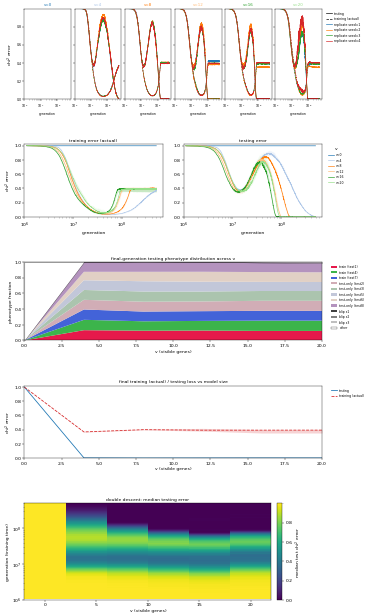
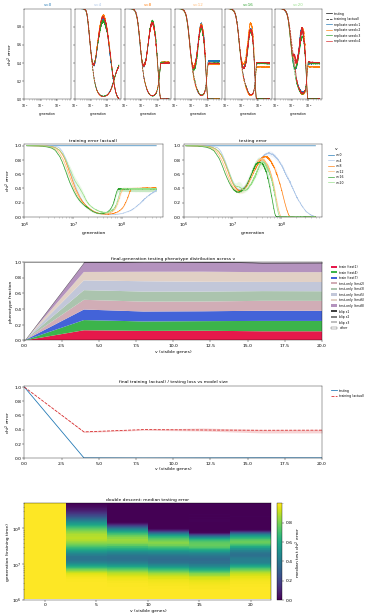
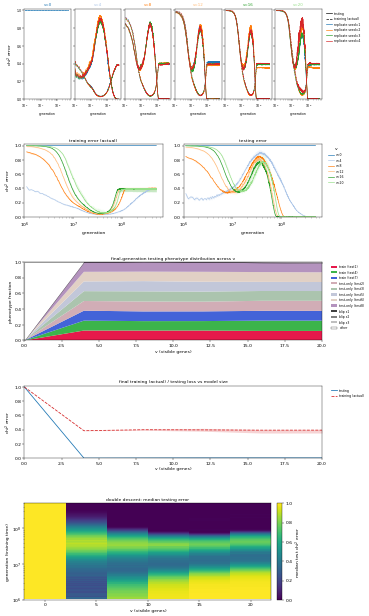
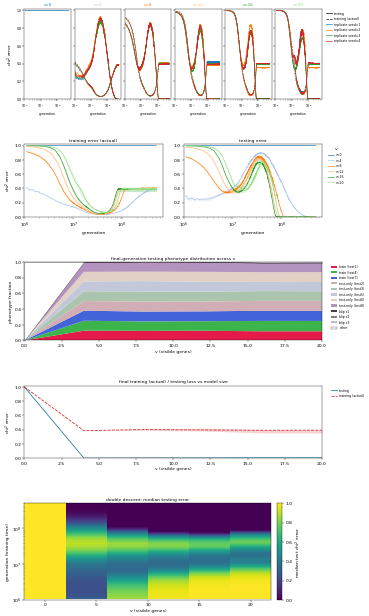
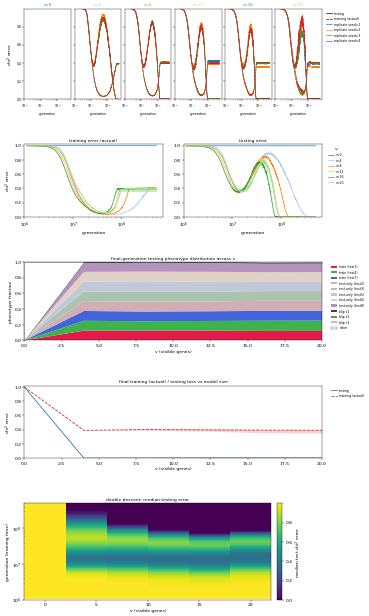
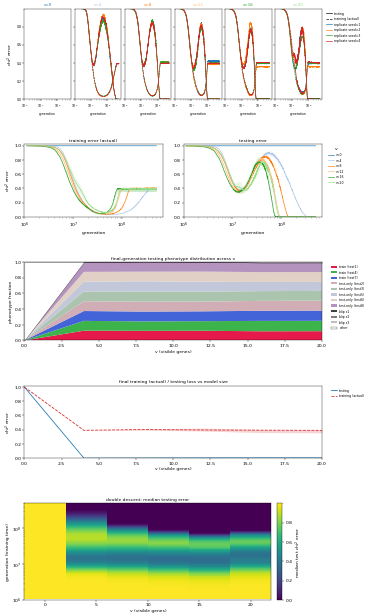
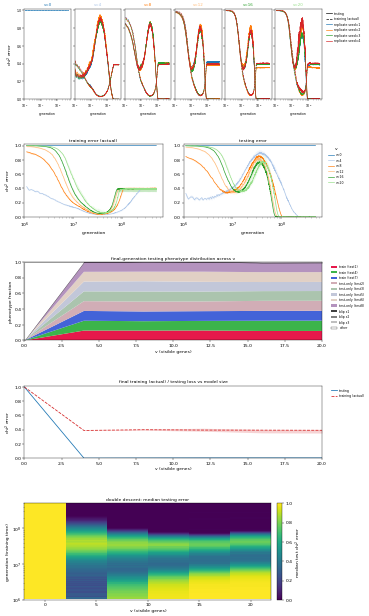
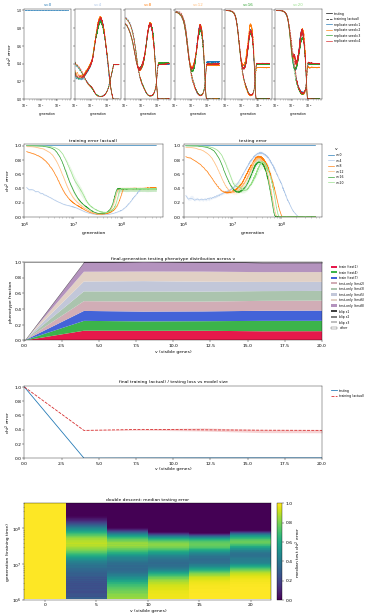
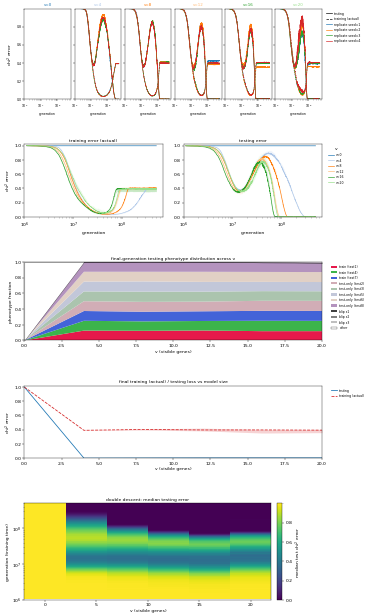
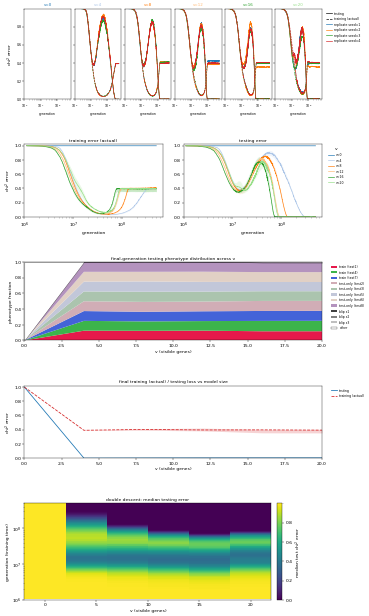
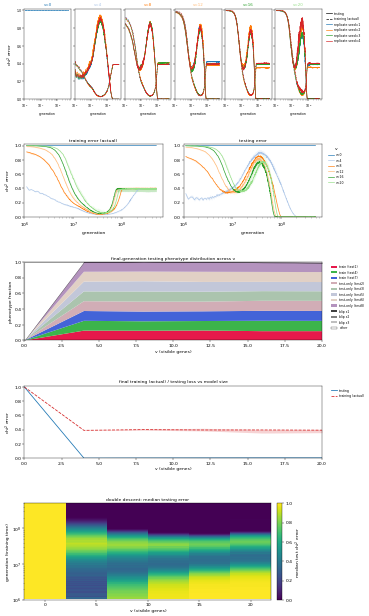
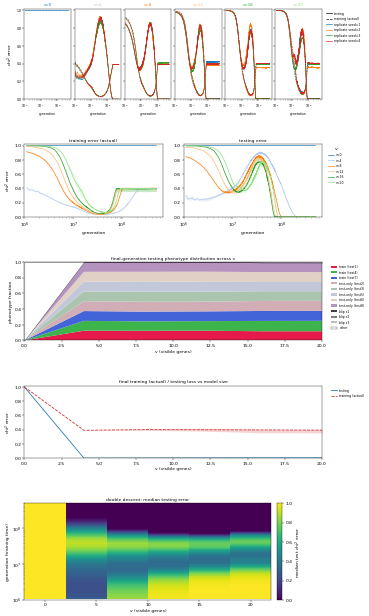
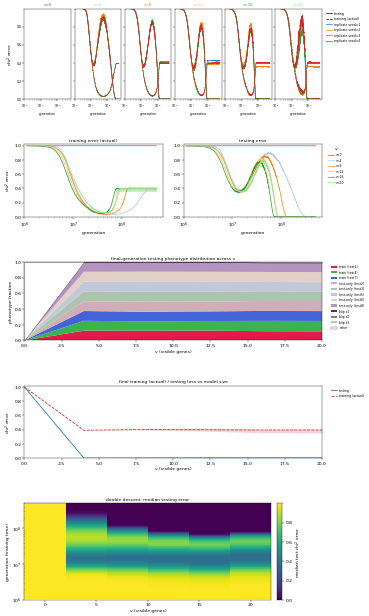
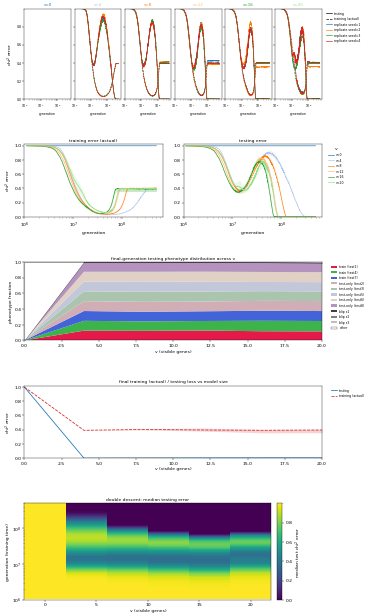
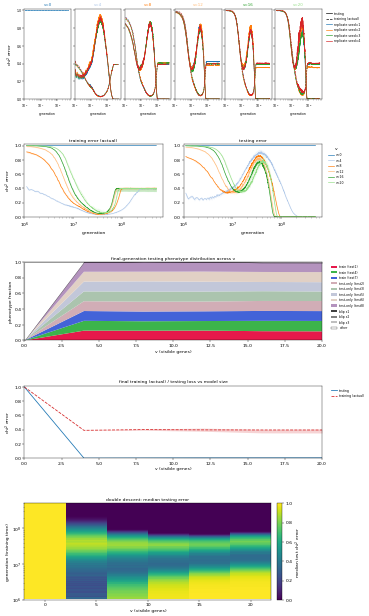
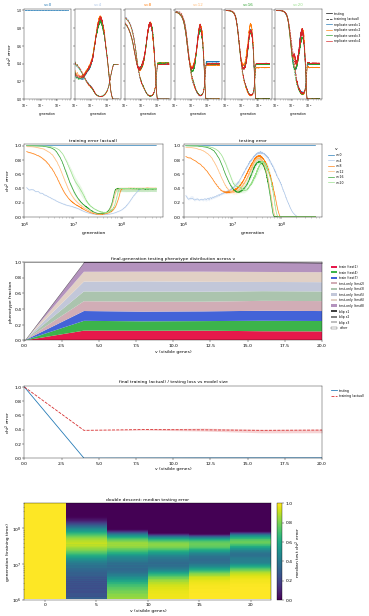
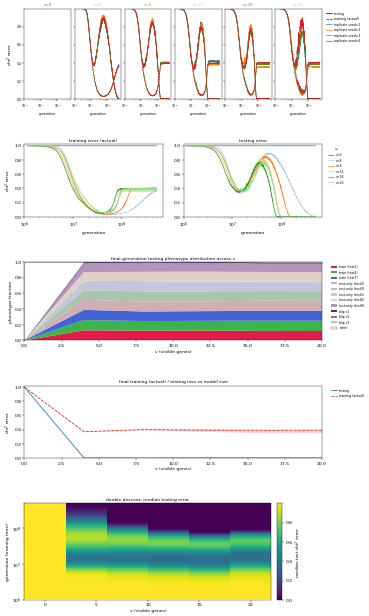
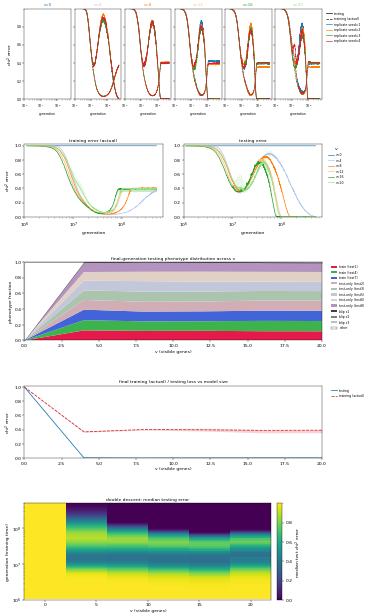
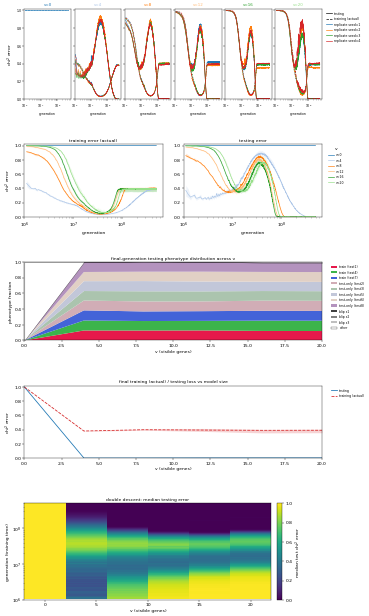
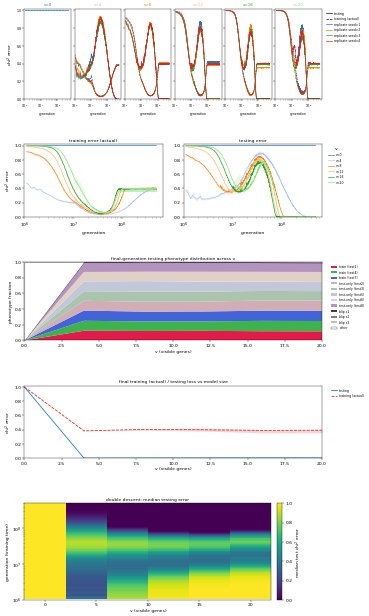
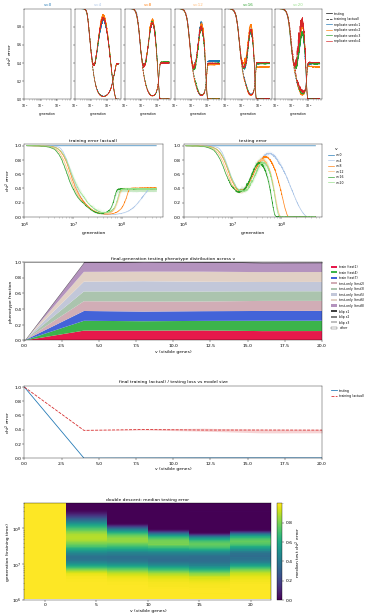
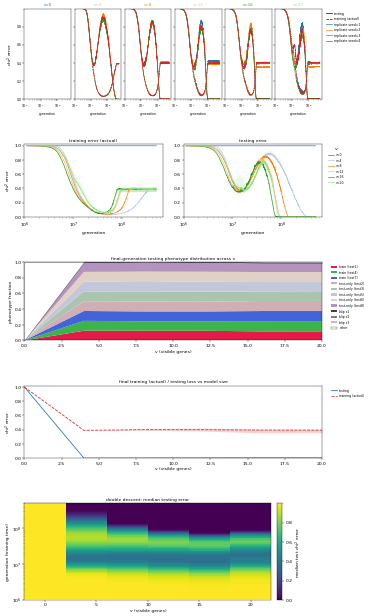
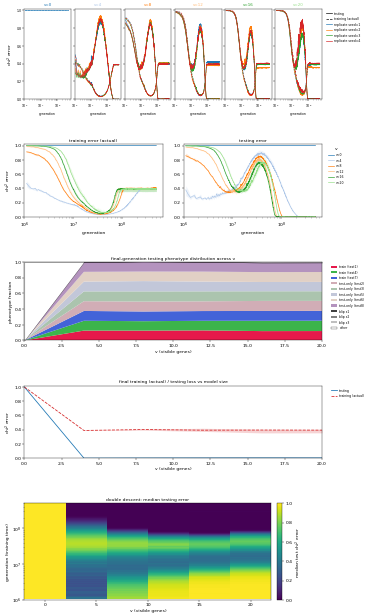
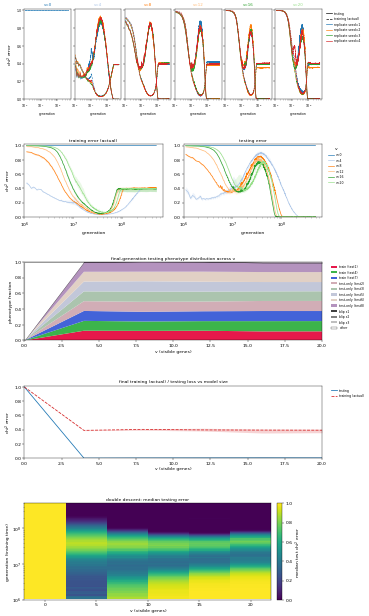
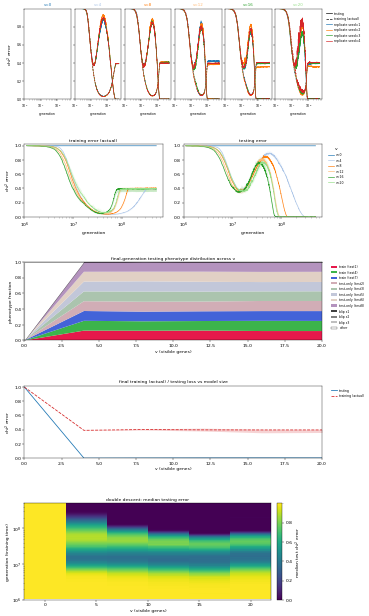
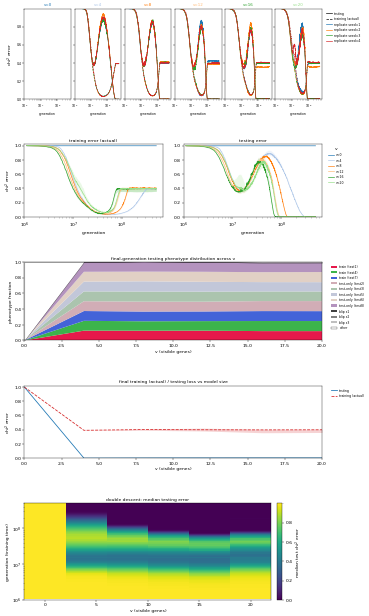
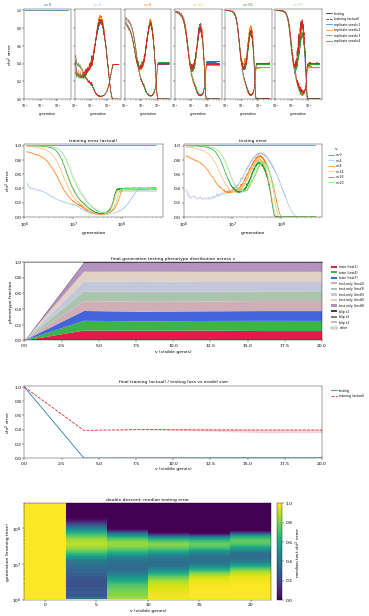
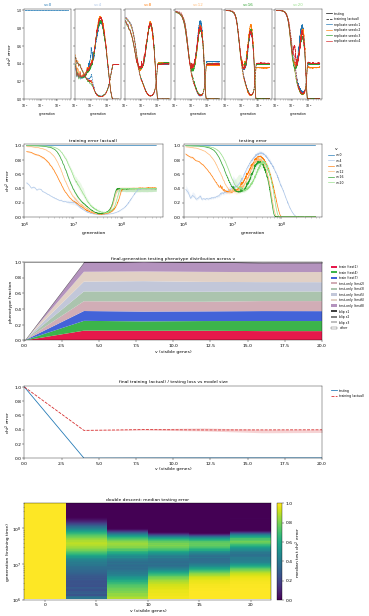
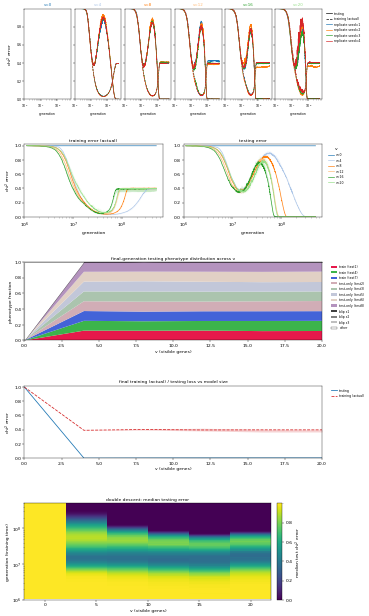
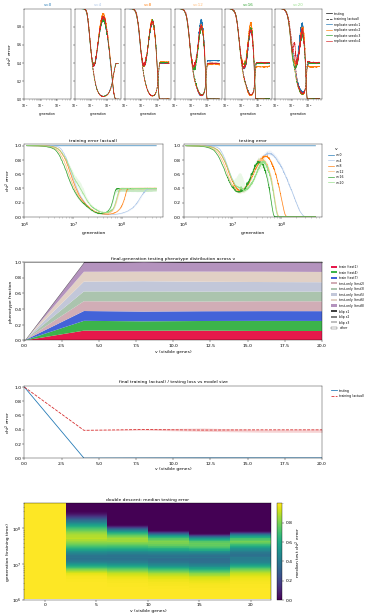
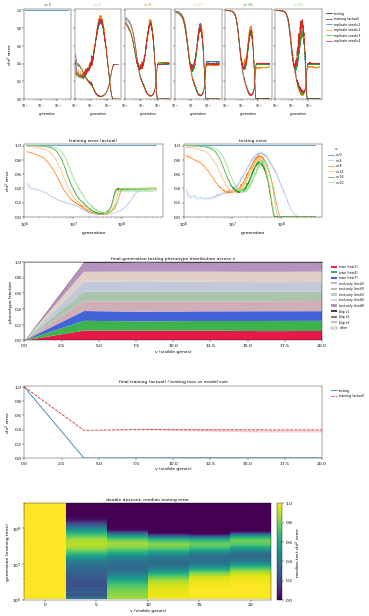
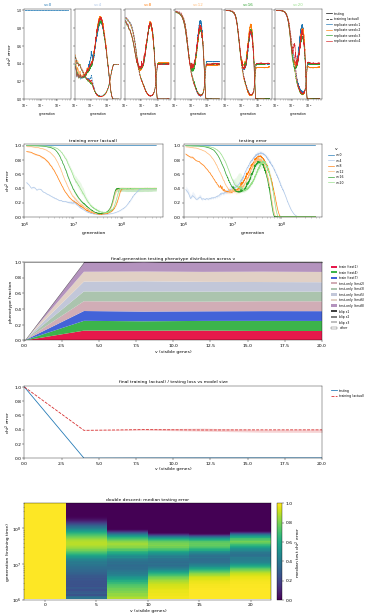
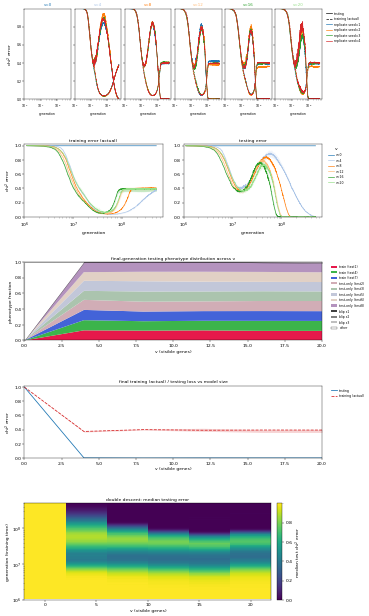
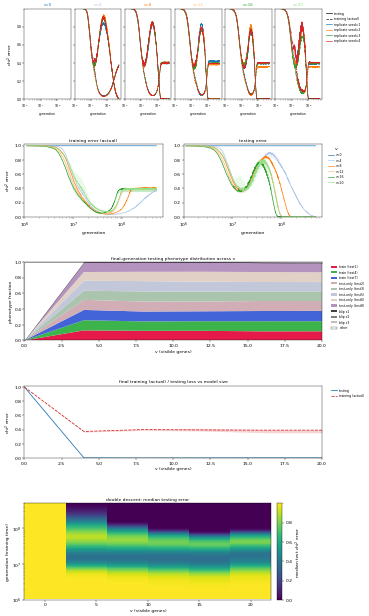
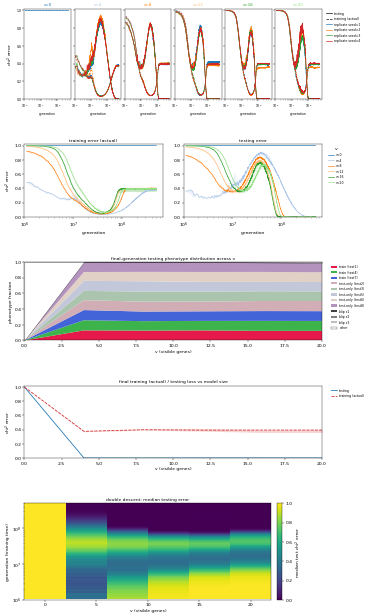
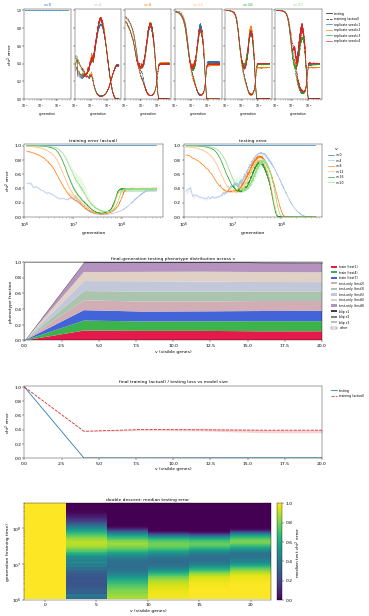
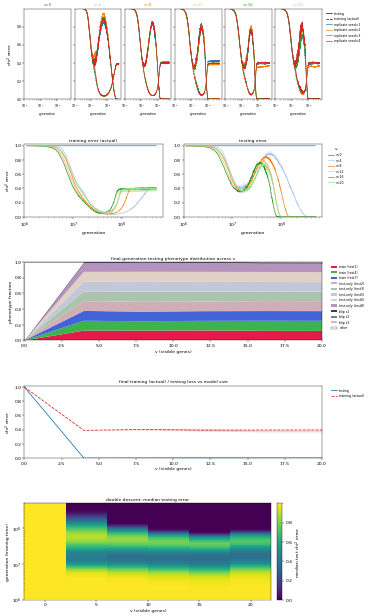
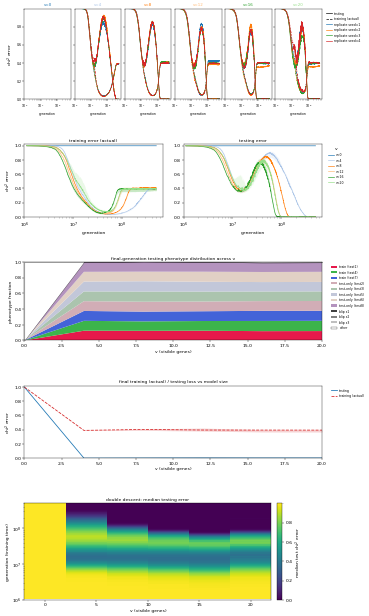
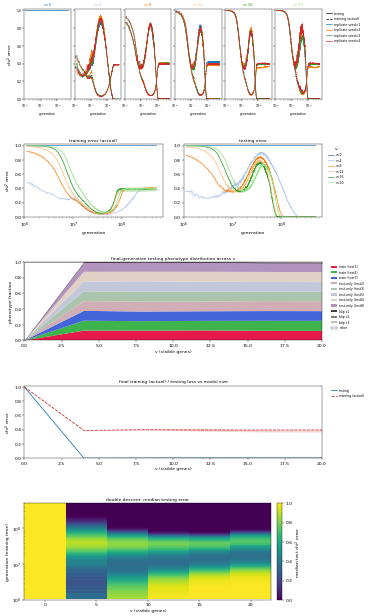
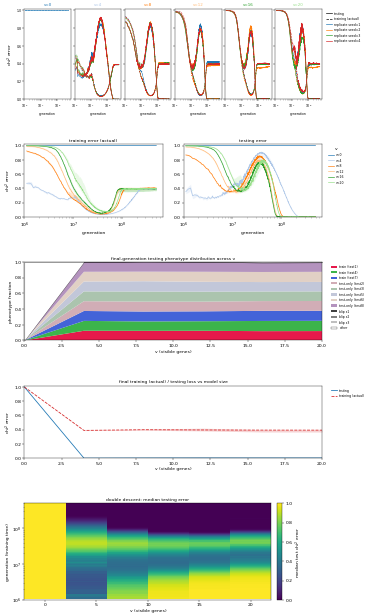
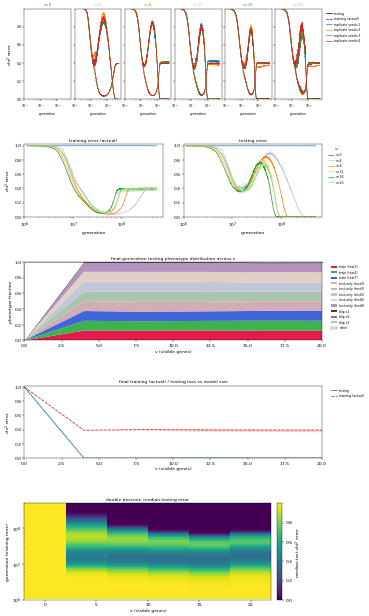
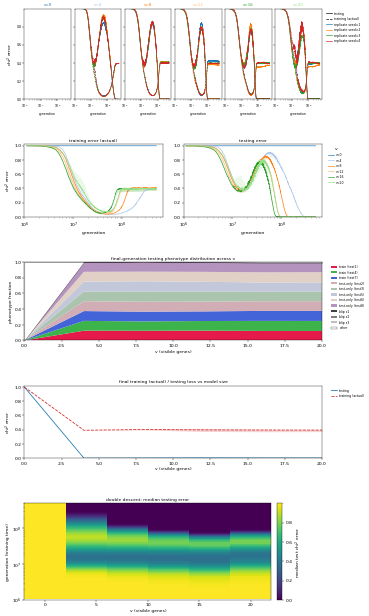
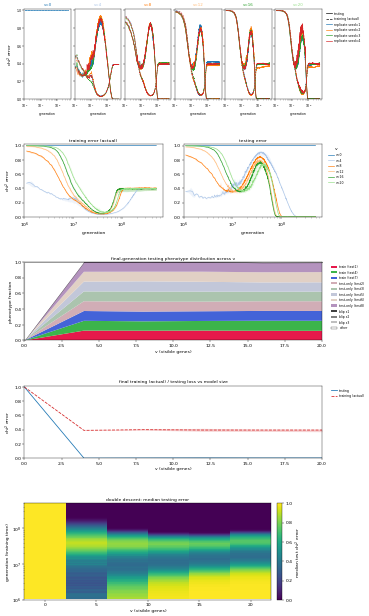
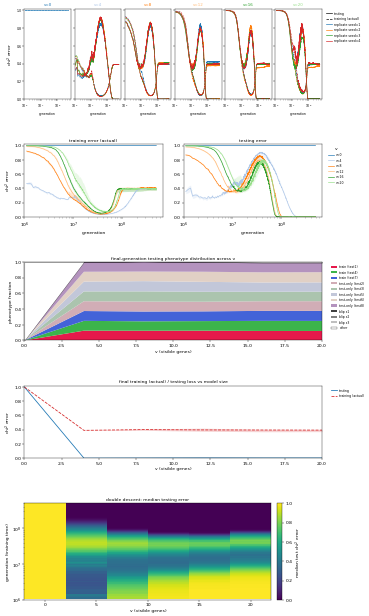
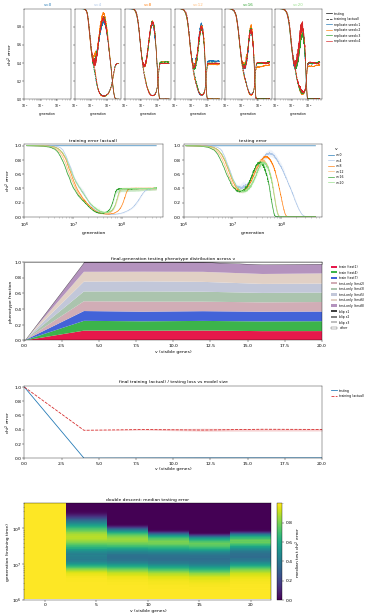
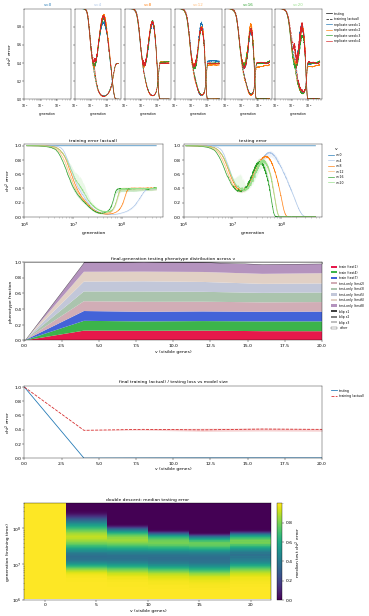
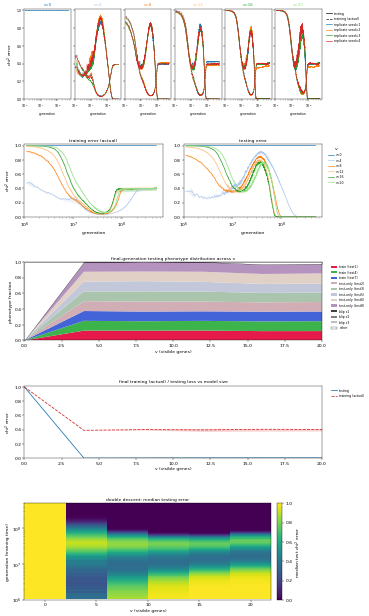
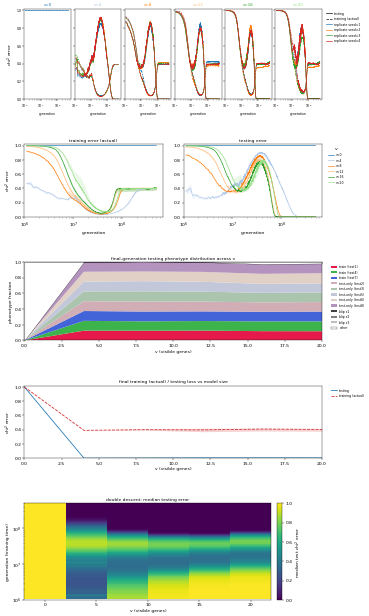
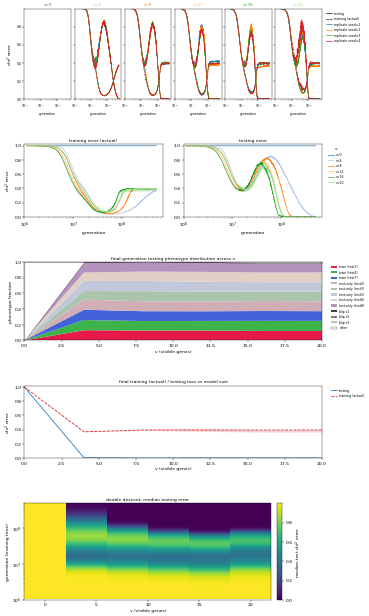
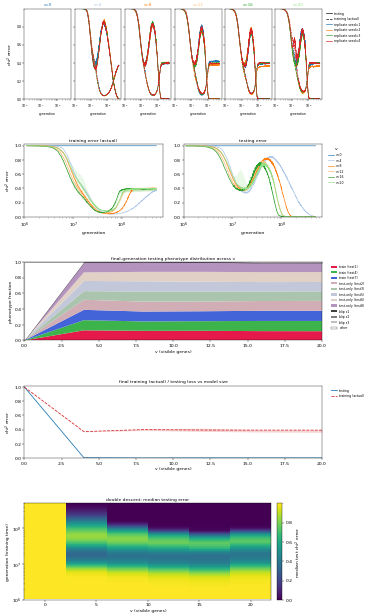
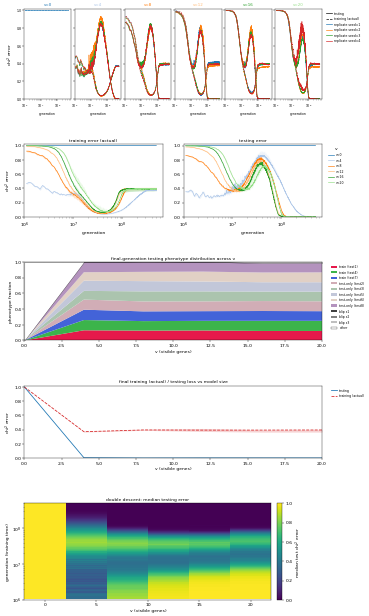
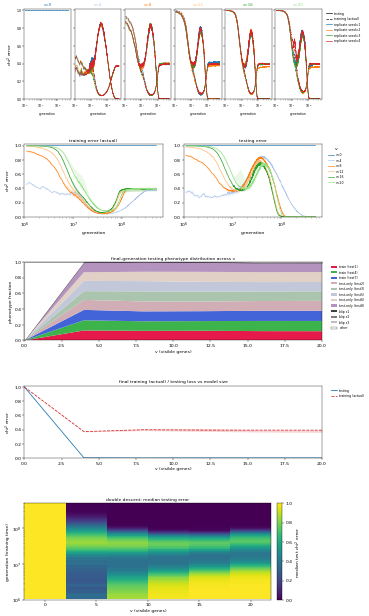
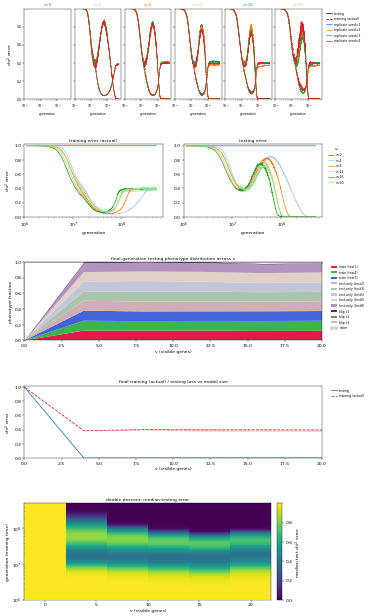
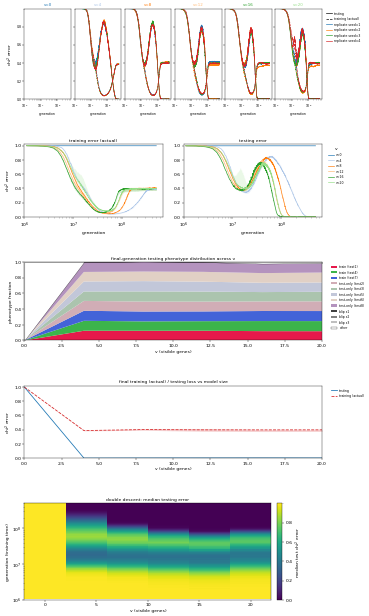
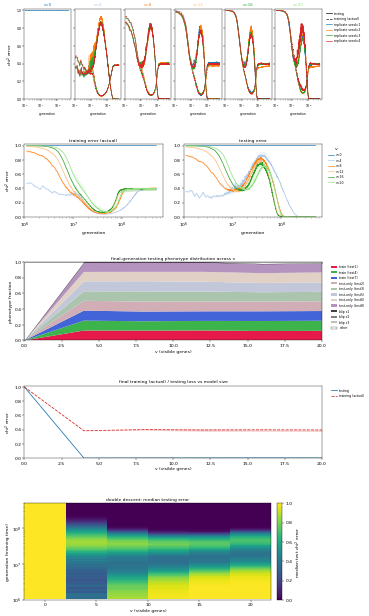
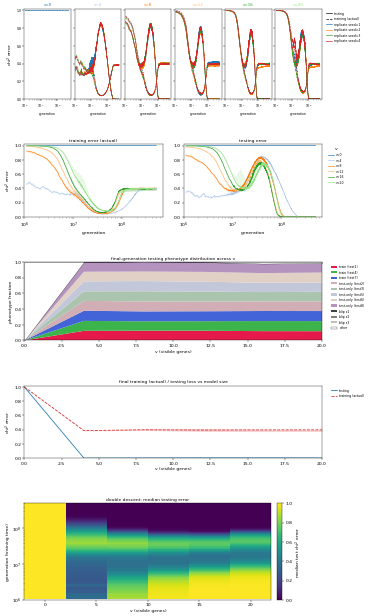
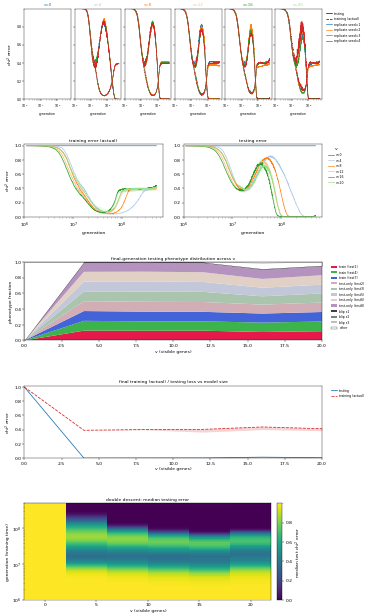
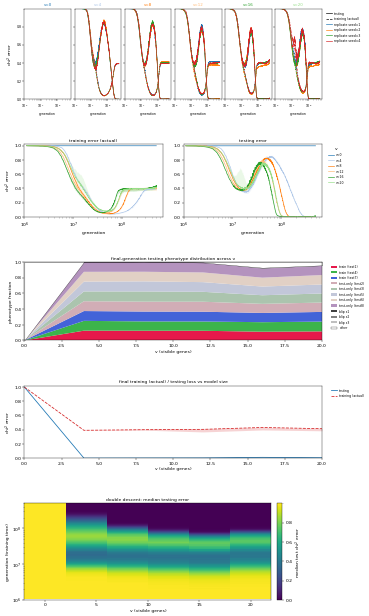
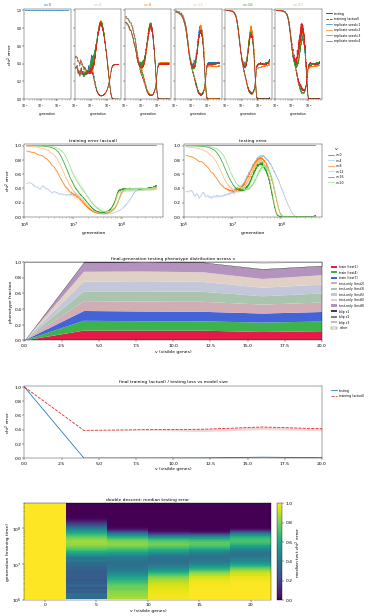
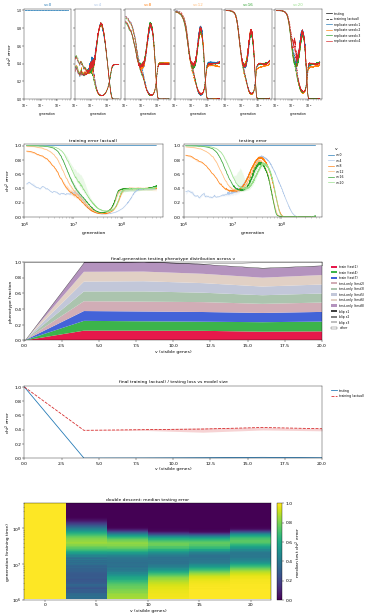
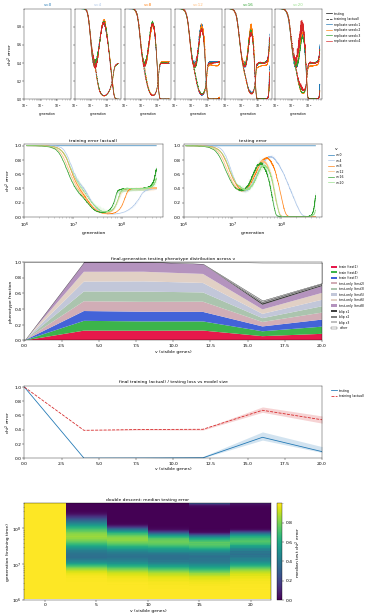
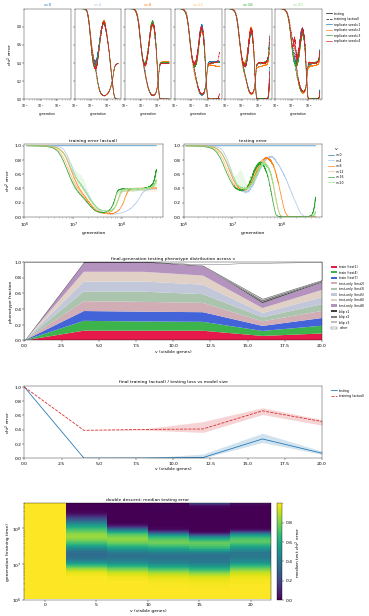
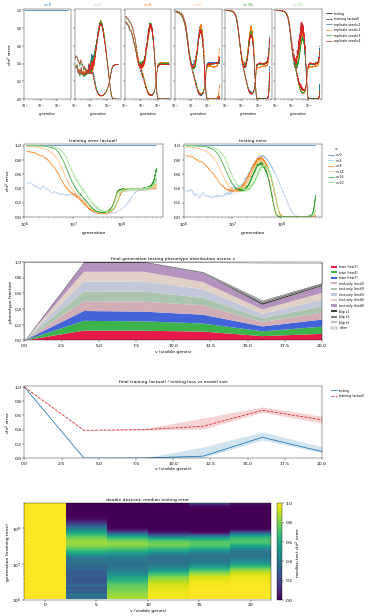
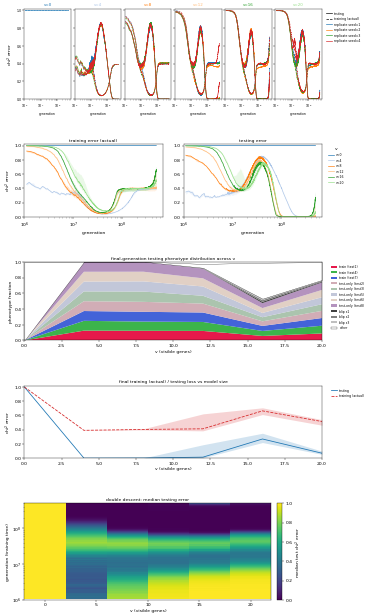
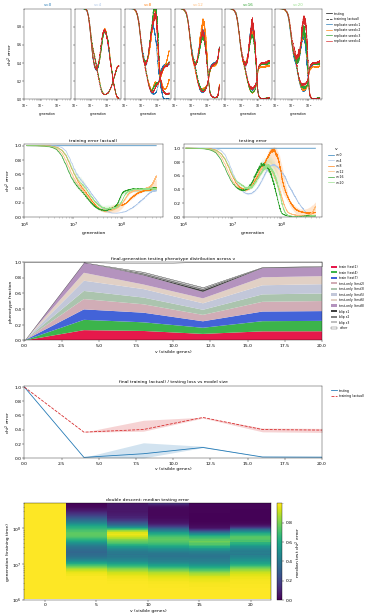
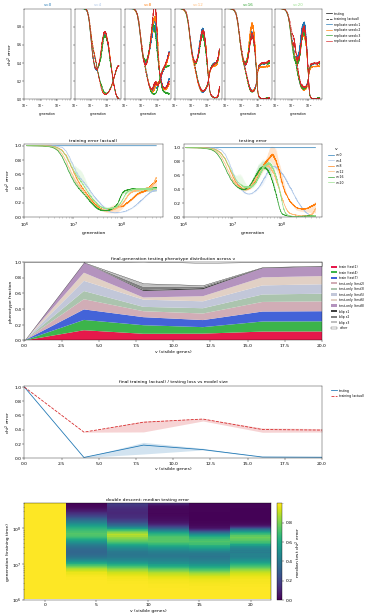
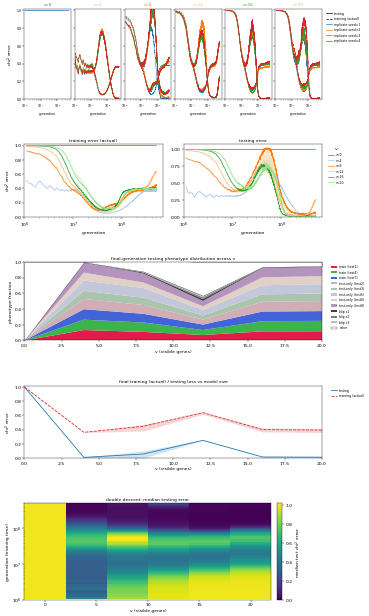
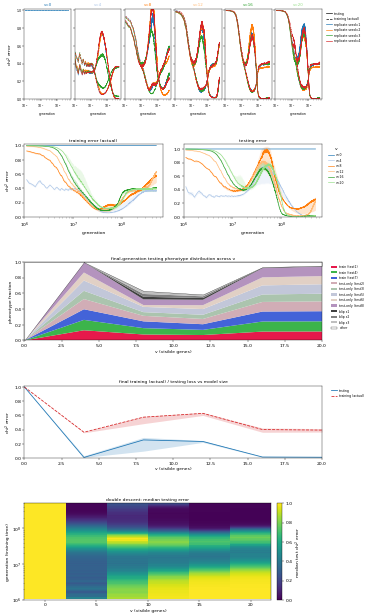
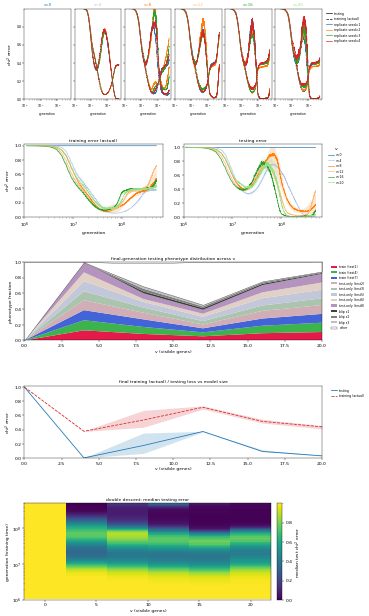
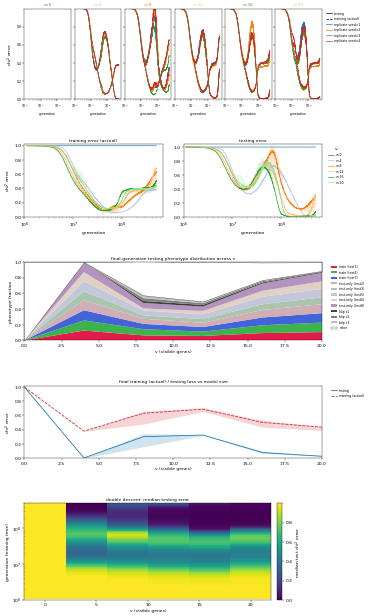
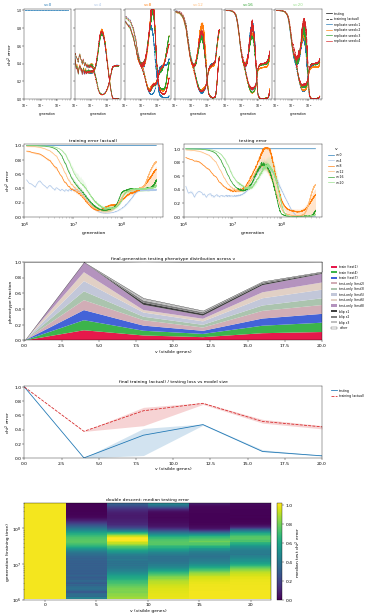
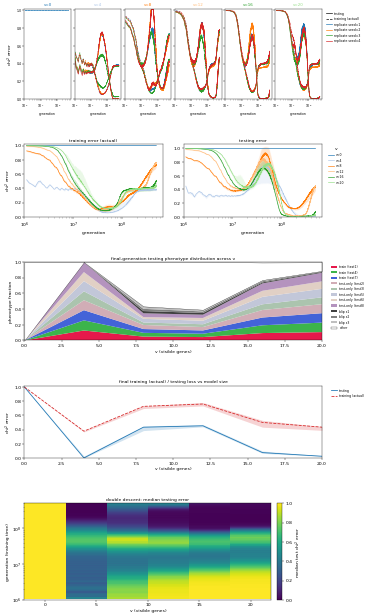
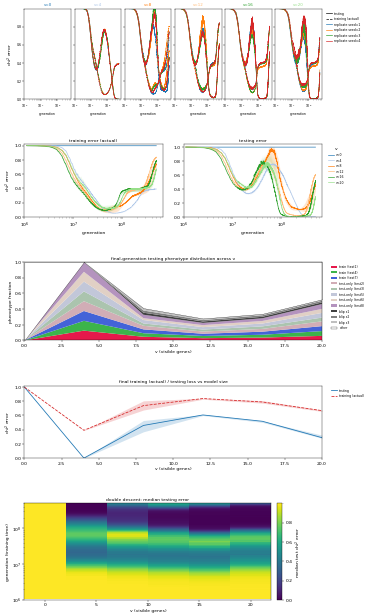
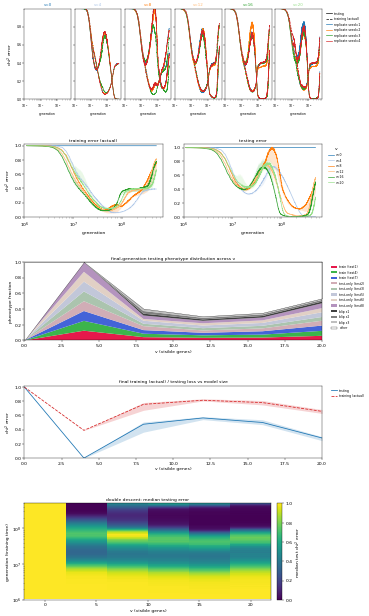
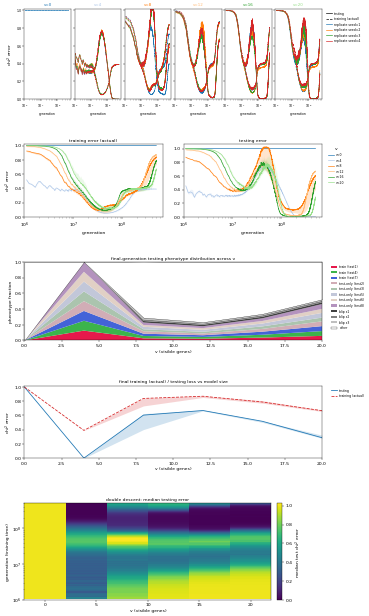
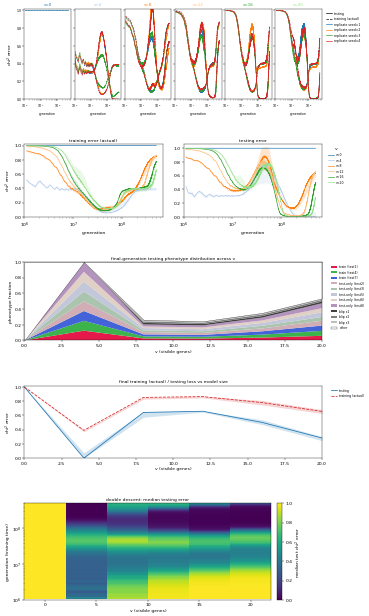
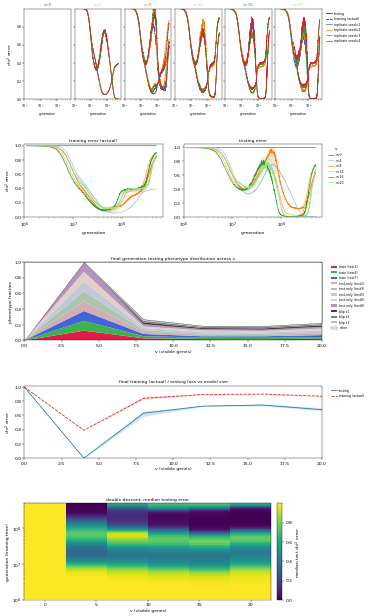
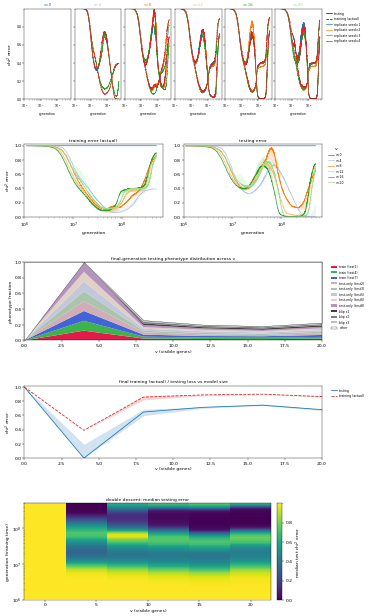
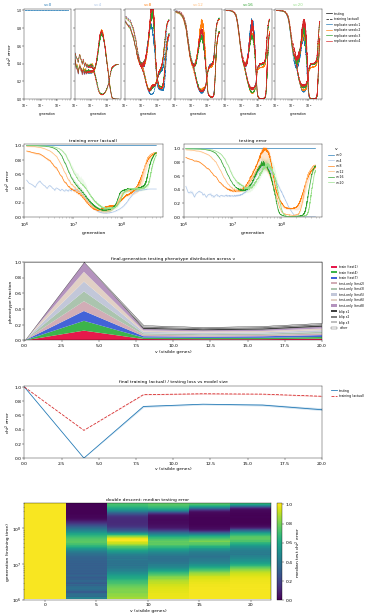
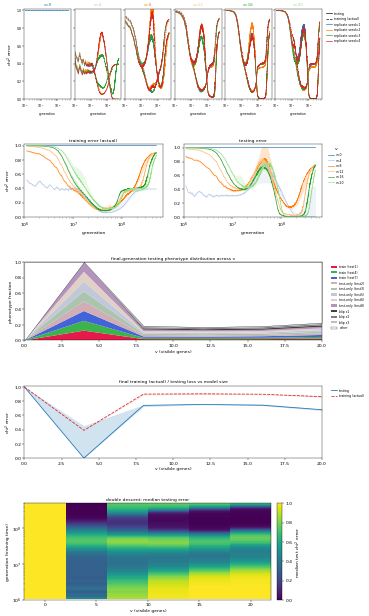

In [ ]:
for _, _cond in conditions.iterrows():
    _mask = np.logical_and.reduce(
        [df[c] == _cond[c] for c in CONDITION_COLS]
    )
    _df_cond = df[_mask]
    _n_replicates = _df_cond["seed"].nunique()

    # text spacer between compound plots (which are themselves
    # deliberately left untitled) identifying which condition follows.
    mo.output.append(
        mo.md(
            f"""
---
**dataset**=`{_cond['dataset']}`
&nbsp;**blip_freq**=`{_cond['blip_freq']}`
&nbsp;**l1_scale**=`{_cond['l1_scale']}`
&nbsp;**l2_scale**=`{_cond['l2_scale']}`
&nbsp;**zero_init**=`{_cond['zero_init']}`
&nbsp;**schedule_mode**=`{_cond['schedule_mode']}`
&nbsp;**n_replicates(seeds)/v**=`{_n_replicates}`
"""
        )
    )

    with tp.teed(
        make_compound_plot,
        _df_cond,
        v_palette,
        teeplot_outattrs={
            "dataset": str(_cond["dataset"]),
            "blipfreq": str(_cond["blip_freq"]),
            "l1scale": str(_cond["l1_scale"]),
            "l2scale": str(_cond["l2_scale"]),
            "zeroinit": str(_cond["zero_init"]),
            "schedulemode": str(_cond["schedule_mode"]),
        },
        teeplot_subdir=pathlib.Path(__file__).stem,
        teeplot_show=False,
    ) as _fig:
        pass

    # mo.output.append renders the figure into the cell's output
    # immediately, so it's safe (and, across ~dozens of conditions,
    # necessary to avoid unbounded memory growth) to close it right
    # after.
    mo.output.append(_fig)
    plt.close(_fig)